In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Spatial density function
def rho(x):
    R = 1.0  # Radius
    if abs(x) <= R:
        return 1.0
    else:
        return 0.1
        
def rejection_sampling_positions(number_samples):
    #number_samples = 1000 # Number of samples
    sampled_positions = []
    
    # Define the domain bounds
    x_min, x_max = -1.0, 1.0
    
    
    # Sample x uniformly from the domain 
    positions = np.random.uniform(x_min, x_max, number_samples)
    # Compute rho(x) in the domain D
    density_values = np.array([rho(x) for x in positions])
    p_max = np.max(density_values) # Maximum of rho(x)
    
    for i in range(len(density_values)):
        r = density_values[i] / p_max # Compute r(x) (rejection sampling)
        
        # Accept/reject based on r
        if np.random.uniform(0, 1) < r:
            sampled_positions.append(positions[i])
            
    num_samples = len(sampled_positions) # Number of samples
    return num_samples, sampled_positions

In [69]:
def u(x):
    # return 0.0
    delta = 5e-3  
    return delta * np.sin(2 * np.pi * x)
    
def T(x):
    return 1.0 + 0.001 * x  

def sample_velocities(sampled_positions):
    # Compute bulk velocity for sampled positions 2D
    bulk_velocities = np.array([u(x) for x in sampled_positions])
    #bulk_velocities = np.array([[0, 0] for x, y in sampled_positions]) 
    
    
    
    # Sample velocities for each position
    sampled_velocities = []
    for x, u_x in zip(sampled_positions, bulk_velocities):
        mean_velocity = [u_x]
        variance = T(x)
        velocity_sample = np.random.normal(mean_velocity, np.sqrt(variance))
        sampled_velocities.append(velocity_sample)
    
    #sampled_velocities = np.array(sampled_velocities)
    return sampled_velocities

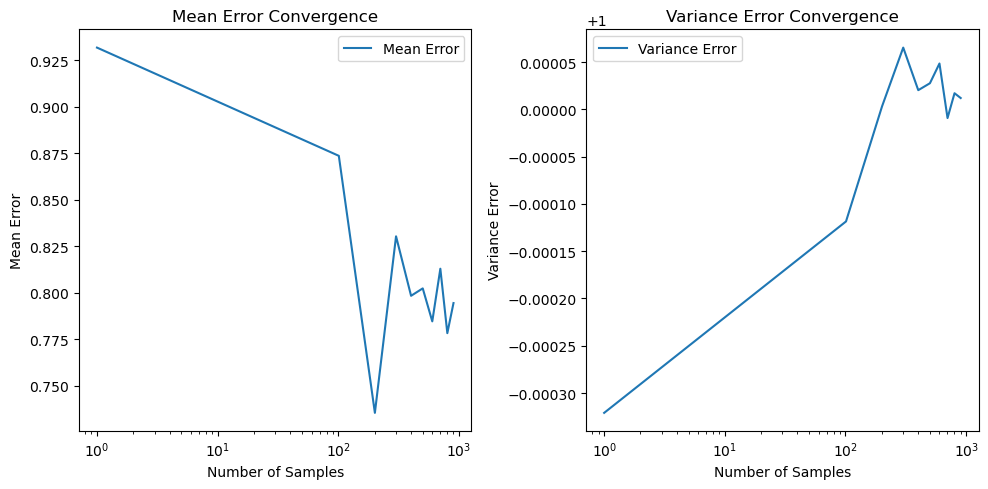

[-3.27024997] [2.93903504]


In [70]:
# Validate velocity sampling 

# Sample size
sample_sizes = np.arange(1, 1000, 100)

# Compute errors in mean and variance
def compute_error_mean_var(num_sample, sampled_positions, sampled_velocities):
    err_mean = []
    err_var = []
    for i in range(num_sample):
        x_sample = sampled_positions[i]
        v_samples = sampled_velocities[i]

        # Compute empirical mean and variance
        empirical_mean = np.mean(v_samples, axis=0)
        empirical_variance = np.var(v_samples, axis=0)

        # Analytical values
        analytical_mean = np.array([u(x_sample)])
        #analytical_mean = np.array([0, 0])
        analytical_variance = T(x_sample)

        err_mean.append(np.abs(empirical_mean - analytical_mean))
        err_var.append(np.abs(empirical_variance - analytical_variance))
    return np.mean(err_mean, axis=0), np.mean(err_var, axis=0)
############################################
# Run the simulation for each sample size
mean_errors = []
var_errors = []
for num_samp in sample_sizes:
    num_sample, sampled_positions = rejection_sampling_positions(num_samp)
    sampled_velocities = sample_velocities(sampled_positions)
    mean_error, var_error = compute_error_mean_var(num_sample, sampled_positions, sampled_velocities)
    mean_errors.append(mean_error)
    var_errors.append(var_error)
###############################################
# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(sample_sizes, mean_errors, label='Mean Error')
plt.xlabel('Number of Samples')
plt.ylabel('Mean Error')
plt.title('Mean Error Convergence')
plt.legend()
plt.xscale('log')

plt.subplot(1, 2, 2)
plt.plot(sample_sizes, var_errors, label='Variance Error')
plt.xlabel('Number of Samples')
plt.ylabel('Variance Error')
plt.title('Variance Error Convergence')
plt.legend()
plt.xscale('log')

plt.tight_layout()
plt.show()
print(min(sampled_velocities), max(sampled_velocities))


In [81]:
# Generate knots
def generate_knot_vector(x_min, x_max, num_basis_functions, p):
    # Generate a clamped uniform knot vector
    num_knots = num_basis_functions + p  +1    # number of knots
    
    # interior knots uniformly
    interior_knots = np.linspace(x_min, x_max, num_knots - 2 * (p + 1) + 2)
    #print(interior_knots)
    # Clamped boundary knots 
    start_knots = [x_min] * (p )
    end_knots = [x_max] * (p )
    
    # Combine boundary and interior knots
    knot_vector = np.concatenate([start_knots, interior_knots, end_knots])
    return knot_vector


p = 2 # Degree of B-spline basis function
num_basis_functions = 20 # number of basis functions
x_min = -1
x_max = 1
knots = generate_knot_vector(x_min, x_max, num_basis_functions, p) # number of knots = num_basis_functions + p + 1  
#knots = np.linspace(-1, 1, num_basis_functions + p + 1 )
#print((knots))
def B_spline_basis(i, p, t, knots):
    # B-spline basis function B_{i,p}(t) 
    if p == 0:
        # B_{i,0}(t)
        return 1.0 if knots[i] <= t < knots[i+1] else 0.0
    else:
        # B_{i,p}(t)
        denominator1 = knots[i + p] - knots[i]
        denominator2 = knots[i + p + 1] - knots[i + 1]
        
        term1 = 0.0 if denominator1 == 0 else (t - knots[i]) / denominator1 * B_spline_basis(i, p - 1, t, knots)
        term2 = 0.0 if denominator2 == 0 else (knots[i + p + 1] - t) / denominator2 * B_spline_basis(i + 1, p - 1, t, knots)
        
        return term1 + term2
        
def phi(i, p, t, knots):
    return B_spline_basis(i, p, t, knots)
    
# basis_functions = []   
# t_values = np.linspace(knots[0], knots[-1], 100)    
# for i in range(len(knots) - p - 1):
#     basis_values = [B_spline_basis(i, p, t, knots) for t in t_values]
#     basis_functions.append(basis_values)
#     #print(basis_functions)
#     plt.plot(t_values, basis_values, label=f'B_{i},{p}(t)')
    
# plt.title(f"B-spline Basis Functions (Degree {p})")
# plt.xlabel("t")
# plt.ylabel("Basis Function Value")
# plt.legend()
# #plt.grid(True)
# plt.show()          

In [82]:
num_basis_space = num_basis_functions  # Number of spatial basis functions
num_basis_velocity = num_basis_functions  # Number of velocity basis functions

# Initialize matrices M_1, M_2 and and coefficient matrix C_hat
M1 = np.zeros((num_basis_space, num_basis_space))  # Spatial matrix
M2 = np.zeros((num_basis_velocity, num_basis_velocity))  # Velocity matrix
C_hat = np.zeros((num_basis_space, num_basis_velocity))
#print(C_hat.shape)


x_grid = np.linspace(-1, 1, 100)
v_grid = np.linspace(-10, 10, 100)
#v_grid = sampled_velocities(x_grid)
#print(len(sample_velocities(x_grid)))

# Compute coefficients C_hat_kl
for k in range(num_basis_velocity):
    for l in range(num_basis_velocity):
        #for x_sp, velocity in zip(x_grid, sample_velocities(x_grid)):
         for x_sp, velocity in zip(sampled_positions, sampled_velocities):
            # print(phi(k, p, x_sp, knots) )
            # print(phi(l, p, velocity, knots))
            C_hat[k, l] += (
                        phi(k, p, x_sp, knots) * 
                        phi(l, p, velocity, knots)
                    )
            #print(C_hat[k, l])
print(C_hat)

# Normalize by the number of samples
#C_hat /= len(x_grid)
C_hat /= num_sample

# Compute spatial matrix M1 using numerical integration
for k in range(num_basis_velocity):
    for l in range(num_basis_velocity):
        integral = 0
        for x in x_grid:
             integral += (
                        phi(k, p, x, knots) * 
                        phi(l, p, x, knots)
                    )
        integral *= (x_grid[-1] - x_grid[0]) / len(x_grid) 
        M1[k, l] = integral
print(M1)

# Compute velocity matrix M2 using numerical integration
for k in range(num_basis_velocity):
    for l in range(num_basis_velocity):
        integral = 0
        for v in v_grid:
             integral += (
                        phi(k, p, v, knots) * 
                        phi(l, p, v, knots)
                    )
        integral *= (v_grid[-1] - v_grid[0]) / len(v_grid) 
        M2[k, l] = integral
print(M2)

# Compute coefficient matrix C
C = np.linalg.inv(M1.T) @ C_hat @ np.linalg.inv(M2)
#print(C)


/tmp/ipykernel_20986/2985578494.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C_hat[k, l] += (


[[4.32005945e-02 1.07065778e-01 1.72292026e-01 4.41997558e-01
  4.54249686e-01 4.37475703e-01 5.78090819e-02 1.29148029e-01
  3.52720928e-01 2.30062483e-02 1.02537314e-01 7.29482037e-01
  4.34320912e-01 5.50410504e-01 1.17601634e+00 8.20078081e-01
  8.13706334e-01 9.10711193e-01 5.11700890e-01 5.74352385e-01]
 [1.65410153e-01 5.96860995e-01 9.97844612e-01 7.33446246e-01
  1.18210263e+00 1.10019552e+00 3.92897012e-01 1.28020985e+00
  2.02285907e+00 4.69687959e-01 6.11808074e-01 1.30938402e+00
  1.42482652e+00 1.80919022e+00 2.24731719e+00 2.02066347e+00
  1.80363674e+00 1.69100127e+00 1.26231795e+00 7.08644036e-01]
 [4.46183286e-02 6.92525563e-01 1.95144416e+00 1.06442734e+00
  1.71035150e+00 1.14803310e+00 1.70129819e+00 2.38907947e+00
  1.27619729e+00 5.10498062e-01 1.37296059e+00 2.01211612e+00
  2.04996340e+00 2.19322209e+00 2.67550107e+00 1.97490612e+00
  1.79981875e+00 1.54265828e+00 1.45212946e+00 8.52796067e-01]
 [5.30848049e-02 8.59687733e-01 2.20143241e+00 1.61087447e+00
  1.2

LinAlgError: Singular matrix

Error Norm: 515.8907985960913


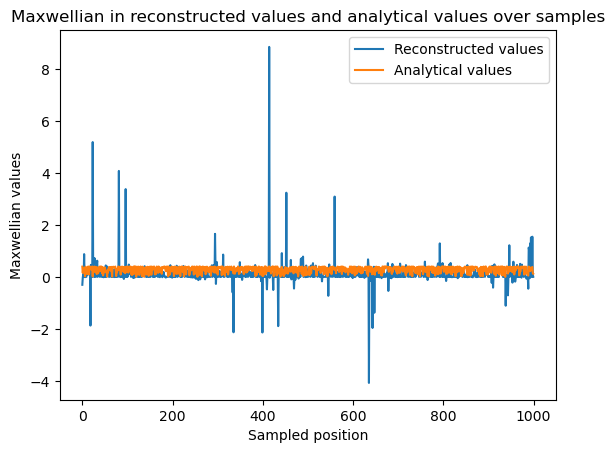

In [75]:
# Analytical Maxwellian function
def analytical_maxwellian(rho, u, T, v):
    d_v = len(v)  # Dimensionality of velocity space
    return rho / ((2 * np.pi * T)**(d_v / 2)) * np.exp(-np.linalg.norm(v - u)**2 / (2 * T))


# Create spatial grid
x_grid = np.linspace(-1, 1, 1000)



#Compute analytical Maxwellian values for comparison
analytical_values = [
    analytical_maxwellian(rho(x), u=[u(x)], T=T(x), v=velocity)
    for x, velocity in zip(x_grid, sample_velocities(x_grid))
]

# Reconstructed Maxwellian function
def reconstructed_maxwellian(x, v, C, p, knots):

    result = 0
    for i in range((num_basis_functions)):
        for j in range((num_basis_functions)):
            result += (
                    C[i, j] *
                    phi(i, p, x, knots) *
                    phi(j, p, v, knots)
                        )
    return result

# Reconstructed values for comparison
reconstructed_values =  [reconstructed_maxwellian(x, v, C, p, knots) for x, v in zip(x_grid, sample_velocities(x_grid))]
#reconstructed_values = [reconstructed_maxwellian(x, y, velocity[0], velocity[1] , C) for (x, y), velocity in zip(sampled_positions, sampled_velocities)]
# resulte = [reconstructed_values[i] / analytical_values[i] for i in range(len(reconstructed_values))]
# print(resulte)

# Compute the error norm \\M_true - M_reconstructed\\_2
analytical_array = np.array(analytical_values)
reconstructed_array = np.array(reconstructed_values)

error_norm = np.linalg.norm(analytical_array - reconstructed_array)
print(f"Error Norm: {error_norm:}")
##################################
# Plot the error reconstructed_values and analytical values of Maxwellian function

fig, ax = plt.subplots()

ax.plot(reconstructed_values, label='Reconstructed values')
ax.plot(analytical_values, label='Analytical values')
ax.set_xlabel('Sampled position')
ax.set_ylabel('Maxwellian values')
ax.set_title('Maxwellian in reconstructed values and analytical values over samples')
ax.legend()
plt.show()

In [84]:
from sympy import symbols, integrate

num_basis_space = num_basis_functions  # Number of spatial basis functions
num_basis_velocity = num_basis_functions  # Number of velocity basis functions

# Initialize matrices M_1, M_2 and and compute coefficient matrix C_hat
M1 = np.zeros((num_basis_space, num_basis_space))  # Spatial matrix
M2 = np.zeros((num_basis_velocity, num_basis_velocity))  # Velocity matrix
C_hat = np.zeros((num_basis_space, num_basis_velocity))
#print(C_hat.shape)

# Compute coefficients C_hat_kl
x_grid = np.linspace(-1, 1, 100)
#print(len(sample_velocities(x_grid)))

# Define variables
s, v = symbols('s v')
def B_spline_basis_ana(i, p, t, knots):
    # B-spline basis function B_{i,p}(t) 
        # B_{i,p}(t)
        denominator1 = knots[i + p] - knots[i]
        denominator2 = knots[i + p + 1] - knots[i + 1]
        
        term1 = 0.0 if denominator1 == 0 else (t - knots[i]) / denominator1 * B_spline_basis_ana(i, p - 1, t, knots)
        term2 = 0.0 if denominator2 == 0 else (knots[i + p + 1] - t) / denominator2 * B_spline_basis_ana(i + 1, p - 1, t, knots)
        
        return term1 + term2
        
def phi_ana(i, p, t, knots):
    return B_spline_basis_ana(i, p, t, knots)
 
for k in range(num_basis_velocity):
    for l in range(num_basis_velocity):
        #for x_sp, velocity in zip(x_grid, sample_velocities(x_grid)):
         for x_sp, velocity in zip(sampled_positions, sampled_velocities):
            # print(phi(k, p, x_sp, knots) )
            # print(phi(l, p, velocity, knots))
            C_hat[k, l] += (
                        phi(k, p, x_sp, knots) * 
                        phi(l, p, velocity, knots)
                    )
            #print(C_hat[k, l])
         M1[k, l] = integrate(phi_ana(k, p, s, knots) * phi_ana(l, p, s, knots), (s, -1, 1))
        #print(phi_ana(k, p, s, knots) )
         M2[k, l] = integrate(phi_ana(k, p, v, knots) * phi_ana(l, p, v, knots), (v, -1, 1))
print(C_hat)
print(M1)
print(M2)
# Normalize by the number of samples
#C_hat /= len(x_grid)
C_hat /= num_sample

# Compute coefficient matrix C
C = np.linalg.inv(M1.T) @ C_hat @ np.linalg.inv(M2)



/tmp/ipykernel_20986/2164923841.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C_hat[k, l] += (


[[4.32005945e-02 1.07065778e-01 1.72292026e-01 4.41997558e-01
  4.54249686e-01 4.37475703e-01 5.78090819e-02 1.29148029e-01
  3.52720928e-01 2.30062483e-02 1.02537314e-01 7.29482037e-01
  4.34320912e-01 5.50410504e-01 1.17601634e+00 8.20078081e-01
  8.13706334e-01 9.10711193e-01 5.11700890e-01 5.74352385e-01]
 [1.65410153e-01 5.96860995e-01 9.97844612e-01 7.33446246e-01
  1.18210263e+00 1.10019552e+00 3.92897012e-01 1.28020985e+00
  2.02285907e+00 4.69687959e-01 6.11808074e-01 1.30938402e+00
  1.42482652e+00 1.80919022e+00 2.24731719e+00 2.02066347e+00
  1.80363674e+00 1.69100127e+00 1.26231795e+00 7.08644036e-01]
 [4.46183286e-02 6.92525563e-01 1.95144416e+00 1.06442734e+00
  1.71035150e+00 1.14803310e+00 1.70129819e+00 2.38907947e+00
  1.27619729e+00 5.10498062e-01 1.37296059e+00 2.01211612e+00
  2.04996340e+00 2.19322209e+00 2.67550107e+00 1.97490612e+00
  1.79981875e+00 1.54265828e+00 1.45212946e+00 8.52796067e-01]
 [5.30848049e-02 8.59687733e-01 2.20143241e+00 1.61087447e+00
  1.2

LinAlgError: Singular matrix